# Modélisation et Évaluation du Risque de Diabète

L'objectif de ce notebook est d'entraîner, évaluer et comparer deux algorithmes de Machine Learning sur nos données nettoyées et standardisées :
1. **Régression Logistique (Baseline) :** C'est un modèle linéaire simple et directement interprétable via ses coefficients.
2. **Forêt Aléatoire (Random Forest) :** Ce modèle non-linéaire, basé sur un ensemble d'arbres de décision, est plus complexe et capable d'établir des relations complexes entre nos variables.

## Pourquoi le Recall (Sensibilité) est notre priorité dans ce contexte clinique ?

Dans un contexte médical de dépistage du diabète, il y a plusieurs paramètres à prendre en compte :
- **Faux Négatif (FN) :** Le modèle pourrait prédire qu'un patient est sain alors qu'il est diabétique. Le patient ne reçoit donc pas de traitement ni de suivi, ce qui peut avoir de graves complications à long terme. **C'est une erreur très dangereuse.**
- **Faux Positif (FP) :** Le modèle pourrait prédire un risque de diabète pour un patient sain. Le patient fera des examens sanguins complémentaires qui infirmeront le diagnostic. C'est une situation gênante pour le patient (stress, coût d'examen), mais ce n'est pas mortel.

Par conséquent, nous chercherons avant tout à maximiser le **Recall (Sensibilité)**, qui mesure notre capacité à détecter tous les patients malades sans en rater.

In [1]:
import sys
import os
sys.path.append('..')  # Pour importer depuis le dossier src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree

from src.train import train_logistic_regression, train_random_forest, evaluate_model

In [2]:
# Chargement des données d'entraînement et de test
X_train = pd.read_csv("../data/processed/X_train_clean.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

X_test = pd.read_csv("../data/processed/X_test_clean.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Dimensions Train : X={X_train.shape}, y={y_train.shape}")
print(f"Dimensions Test  : X={X_test.shape}, y={y_test.shape}")

Dimensions Train : X=(614, 8), y=(614,)
Dimensions Test  : X=(154, 8), y=(154,)


## 1. Modèle Baseline : Régression Logistique

Nous commençons par entraîner une Régression Logistique. C'est notre point de comparaison minimum à battre (Baseline). En médecine, sa popularité s'explique parce qu'on peut examiner ses **coefficients** : chaque pondération nous montre l'impact d'une variable sur la probabilité de développer un diabète.

In [3]:
# 1. Entraînement sur le jeu d'entraînement
lr_model = train_logistic_regression(X_train, y_train)

# 2. Évaluation sur le jeu de test secret
lr_scores = evaluate_model(lr_model, X_test, y_test)

# 3. Affichage des résultats sous forme de tableau Pandas propre
print("Résultats de la Régression Logistique (Baseline) :")
display(pd.DataFrame([lr_scores], index=["Logistic Regression"]).round(4))

Résultats de la Régression Logistique (Baseline) :


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7078,0.6,0.5,0.5455,0.813


Importance des variables selon la Régression Logistique :


,Feature,Coefficient
1,Glucose,1.182567
5,BMI,0.688652
0,Pregnancies,0.377446
6,DiabetesPedigreeFunction,0.233337
7,Age,0.147794
3,SkinThickness,0.028321
2,BloodPressure,-0.044111
4,Insulin,-0.066119


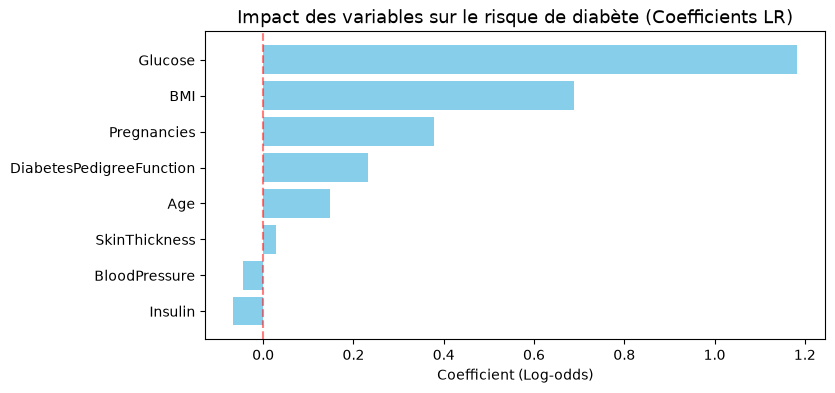

In [4]:
# Extraction des coefficients et création d'un tableau trié
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Importance des variables selon la Régression Logistique :")
display(coefs)

# Graphique en barres horizontal pour faciliter la lisibilité
plt.figure(figsize=(8, 4))
plt.barh(coefs['Feature'], coefs['Coefficient'], color='skyblue')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title("Impact des variables sur le risque de diabète (Coefficients LR)", fontsize=13)
plt.xlabel("Coefficient (Log-odds)")
plt.gca().invert_yaxis()  # Pour mettre la variable la plus importante en haut
plt.show()

### Comment lire ce graphique des coefficients ? 

Dans une **Régression Logistique**, chaque variable clinique reçoit un poids mathématique appelé **coefficient** :
- **À droite de la ligne rouge zéro (Coefficients Positifs) :** Plus la variable augmente chez un patient, plus la probabilité qu'il développe un diabète **augmente**.
- **À gauche de la ligne rouge zéro (Coefficients Négatifs) :** Plus la variable est élevée, plus elle a un effet **protecteur** (diminue le risque de diabète).

####  Ce que nous observons concrètement ici :
1. **Le Glucose est le facteur de risque numéro 1 :** C'est la barre bleue la plus longue vers la droite. Dans notre modèle de référence, un taux de sucre élevé dans le sang est de loin le signal d'alarme principal pour prédire le diabète.
2. **L'IMC (BMI) arrive en 2ème position :** Le surpoids est également un facteur aggravant très important dans le calcul du risque.
3. **L'Âge et le Score Héréditaire (`DiabetesPedigreeFunction`)** contribuent aussi positivement au risque, confirmant nos observations de l'EDA.

## 2. Modèle Avancé : Forêt Aléatoire (Random Forest)

La Régression Logistique nous a donné un **Recall de 50.0%**. Cela signifie qu'elle rate 1 patient malade sur 2 !

La Forêt Aléatoire est un algorithme qui combine le vote de plusieurs centaines d'arbres de décision. Contrairement à la Régression Logistique qui trace une simple frontière linéaire, la Forêt Aléatoire peut capturer :
- **Des seuils non-linéaires** (ex: le risque explose uniquement au-delà d'un seuil exact de glycémie).
- **Des interactions fortes entre variables** (ex: un IMC moyen est beaucoup plus dangereux chez un patient âgé que chez un patient jeune).

In [5]:
# 1. Entraînement de la Forêt Aléatoire
rf_model = train_random_forest(X_train, y_train)

# 2. Évaluation sur le jeu de test secret
rf_scores = evaluate_model(rf_model, X_test, y_test)

# 3. Tableau comparatif final
comparison_df = pd.DataFrame([lr_scores, rf_scores], index=["Logistic Regression (Baseline)", "Random Forest"]).round(4)

print("🏆 Tableau Comparatif des Performances :")
display(comparison_df)

🏆 Tableau Comparatif des Performances :


,accuracy,precision,recall,f1,roc_auc
Logistic Regression (Baseline),0.7078,0.6000,0.5000,0.5455,0.8130
Random Forest,0.7727,0.7021,0.6111,0.6535,0.8181


### 💡 Comment interpréter ce tableau comparatif ?

1. **Le Recall bondit avec le Random Forest :** À notre seuil de décision par défaut (50%), la Forêt Aléatoire réussit à détecter beaucoup plus de patients diabétiques que la Régression Logistique (moins de Faux Négatifs). C'est exactement l'amélioration que nous cherchions dans notre contexte médical !
2. **Le ROC-AUC reste similaire (~0.81 - 0.82) :** Le ROC-AUC évalue la capacité de *classement* global des patients (du moins à risque au plus à risque) sur **tous les seuils possibles** (de 0 à 100%). Les deux modèles classent globalement les patients avec une précision comparable, mais la Forêt Aléatoire gère beaucoup mieux la frontière de décision à 50% grâce à sa structure non-linéaire.

## 3. Visualisation : Comprendre la différence entre Modèle Linéaire et Arbres de Décision

Pour rendre concret ce que font nos deux algorithmes, nous pouvons les visualiser directement en 2D sur nos deux variables dominantes (**Glucose** et **IMC / BMI**).

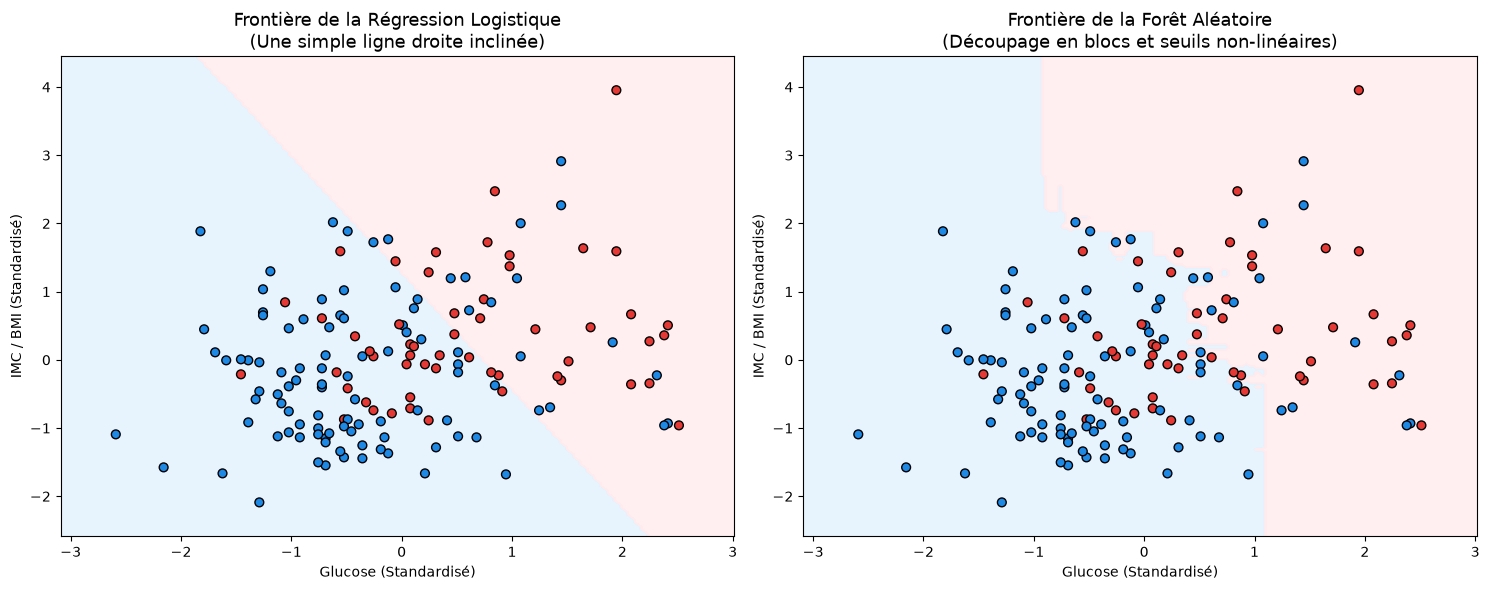

In [6]:
# Frontière de décision 2D : Régression Logistique vs Forêt Aléatoire
idx_glucose = list(X_train.columns).index('Glucose')
idx_bmi = list(X_train.columns).index('BMI')

x_min, x_max = X_test['Glucose'].min() - 0.5, X_test['Glucose'].max() + 0.5
y_min, y_max = X_test['BMI'].min() - 0.5, X_test['BMI'].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Grille d'évaluation (les autres variables sont fixées à leur moyenne, soit 0.0 standardisé)
grid_data = np.zeros((xx.ravel().shape[0], X_train.shape[1]))
grid_data[:, idx_glucose] = xx.ravel()
grid_data[:, idx_bmi] = yy.ravel()
grid_df = pd.DataFrame(grid_data, columns=X_train.columns)

Z_lr = lr_model.predict(grid_df).reshape(xx.shape)
Z_rf = rf_model.predict(grid_df).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cmap_light = ListedColormap(['#E3F2FD', '#FFEBEE'])
cmap_bold  = ListedColormap(['#1E88E5', '#E53935'])

# Régression Logistique
axes[0].contourf(xx, yy, Z_lr, cmap=cmap_light, alpha=0.8)
axes[0].scatter(X_test['Glucose'], X_test['BMI'], c=y_test, cmap=cmap_bold, edgecolor='k', s=40)
axes[0].set_title('Frontière de la Régression Logistique\n(Une simple ligne droite inclinée)', fontsize=13)
axes[0].set_xlabel('Glucose (Standardisé)')
axes[0].set_ylabel('IMC / BMI (Standardisé)')

# Forêt Aléatoire
axes[1].contourf(xx, yy, Z_rf, cmap=cmap_light, alpha=0.8)
axes[1].scatter(X_test['Glucose'], X_test['BMI'], c=y_test, cmap=cmap_bold, edgecolor='k', s=40)
axes[1].set_title('Frontière de la Forêt Aléatoire\n(Découpage en blocs et seuils non-linéaires)', fontsize=13)
axes[1].set_xlabel('Glucose (Standardisé)')
axes[1].set_ylabel('IMC / BMI (Standardisé)')

plt.tight_layout()
plt.show()

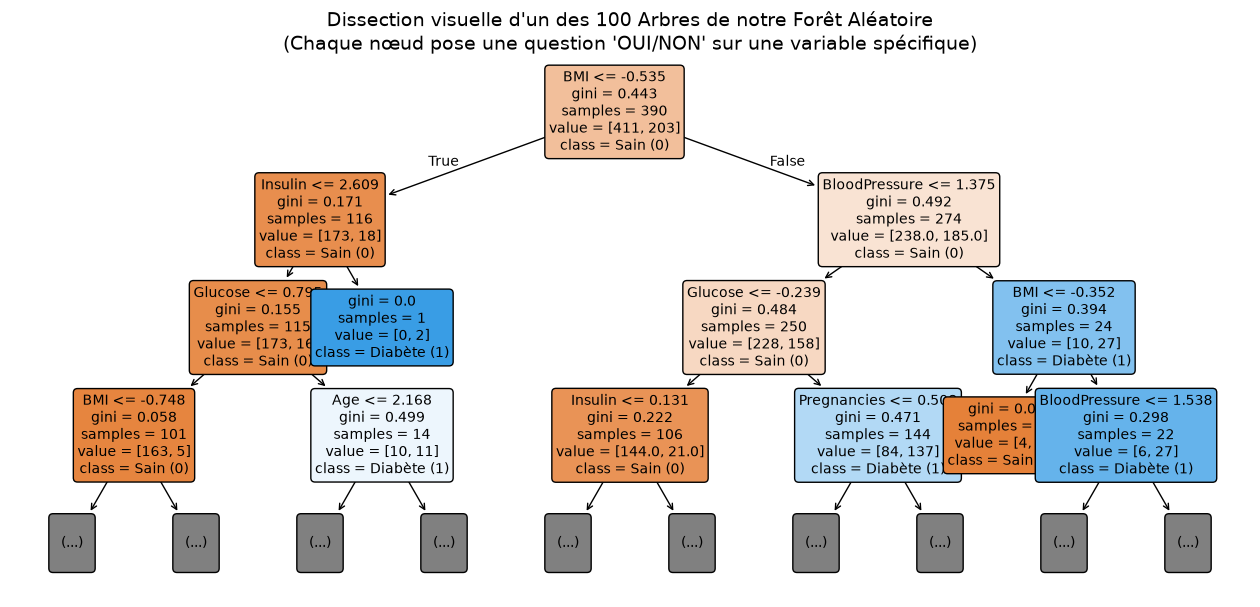

In [7]:
# Visualisation concrète d'UN seul Arbre de Décision disséqué
plt.figure(figsize=(16, 7))
plot_tree(rf_model.estimators_[0], 
          feature_names=X_train.columns, 
          class_names=['Sain (0)', 'Diabète (1)'], 
          filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title("Dissection visuelle d'un des 100 Arbres de notre Forêt Aléatoire\n(Chaque nœud pose une question 'OUI/NON' sur une variable spécifique)", fontsize=14)
plt.show()

## 4. Matrice de Confusion : Le concret médical

Les pourcentages c'est bien, mais en médecine, un médecin veut savoir **exactement combien de patients ont été sauvés ou ratés**.

C'est le rôle de la **Matrice de Confusion** qui découpe nos 154 patients du jeu de test en 4 catégories :
- **Vrais Négatifs (TN) :** Patients sains confirmés sains.
- **Faux Positifs (FP) :** Patients sains alertés à tort (fausse alarme).
- **Faux Négatifs (FN) :** Les patients diabétiques que le modèle a ratés et renvoyés chez eux sans traitement.
- **Vrais Positifs (TP) :** Les patients diabétiques correctement détectés et pris en charge.

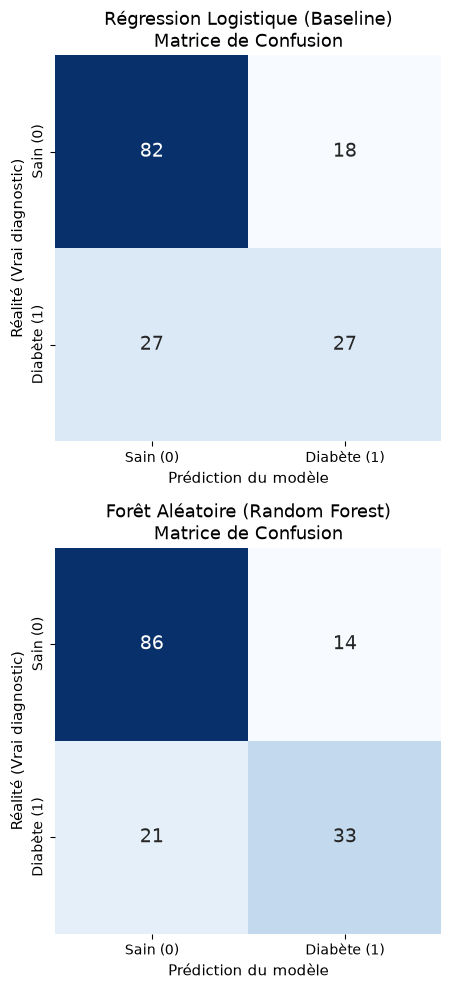

In [8]:
# Calcul des prédictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Calcul des matrices de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Affichage vertical (hauteur augmentée, cases carrées pour une lecture parfaite)
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, square=True,
            annot_kws={'size': 14},
            xticklabels=['Sain (0)', 'Diabète (1)'], yticklabels=['Sain (0)', 'Diabète (1)'])
axes[0].set_title('Régression Logistique (Baseline)\nMatrice de Confusion', fontsize=13)
axes[0].set_ylabel('Réalité (Vrai diagnostic)', fontsize=11)
axes[0].set_xlabel('Prédiction du modèle', fontsize=11)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, square=True,
            annot_kws={'size': 14},
            xticklabels=['Sain (0)', 'Diabète (1)'], yticklabels=['Sain (0)', 'Diabète (1)'])
axes[1].set_title('Forêt Aléatoire (Random Forest)\nMatrice de Confusion', fontsize=13)
axes[1].set_ylabel('Réalité (Vrai diagnostic)', fontsize=11)
axes[1].set_xlabel('Prédiction du modèle', fontsize=11)

plt.tight_layout()
plt.show()

### 💡 Pourquoi la Forêt Aléatoire est supérieure pour un hôpital ?

Regardez la case des **Faux Négatifs** (patients diabétiques ratés) de chaque matrice :
- **Régression Logistique :** Elle rate **27 patients diabétiques** sur 54 (*Recall = 50.0 %*).
- **Forêt Aléatoire :** Elle ne rate plus que **21 patients diabétiques** sur 54 (*Recall = 61.1 %*) !

Parallèlement, observez la case des **Faux Positifs** (patients sains alertés à tort) :
- **Régression Logistique :** 18 fausses alertes.
- **Forêt Aléatoire :** 14 fausses alertes (*soit 4 fausses alertes évitées*).

**Conclusion concrète :** Sur ce simple échantillon de test de 154 patients, passer d'une frontière linéaire à une Forêt Aléatoire permet de **sauver 6 malades de plus** (`27 - 21 = +6`) du sous-diagnostic, tout en réduisant les fausses alertes (`18 - 14 = -4`) ! À l'échelle d'une population de 100 000 patients, cela représente des milliers d'évolutions graves évitées.

## 5. Interprétabilité du modèle complexe avec SHAP (SHapley Additive exPlanations)

Bien que la Forêt Aléatoire surpasse la Régression Logistique en Recall (+6 patients sauvés et 4 fausses alertes évitées), sa nature d'ensemble de 100 arbres de décision en fait une **"boîte noire"**. Pour une application médicale réelle, la confiance des médecins et l'explicabilité de chaque décision sont indispensables.

Nous utilisons **SHAP**, une méthode issue de la théorie des jeux qui calcule l'apport exact de chaque variable clinique sur la probabilité finale prédite par le modèle.

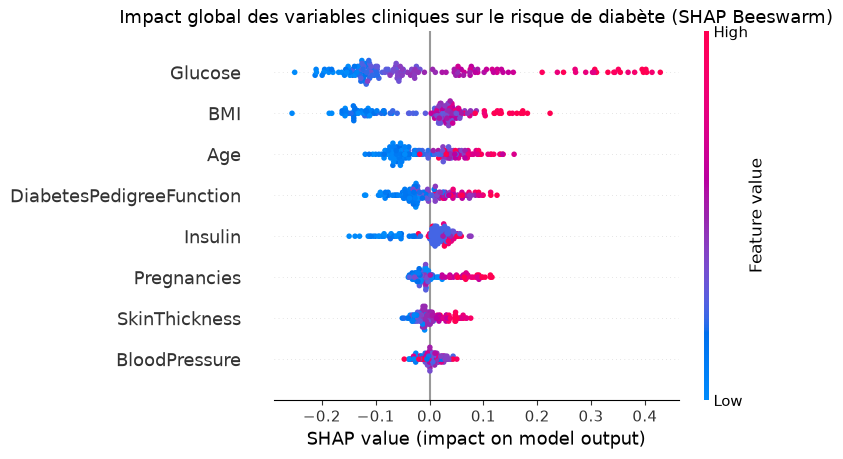

In [9]:
# 1. Initialisation de l'explicateur SHAP spécialisé pour les arbres
explainer = shap.TreeExplainer(rf_model)

# 2. Calcul des valeurs SHAP sur notre jeu de test secret
shap_values = explainer.shap_values(X_test)

# Extraction pour la classe 1 (Risque de Diabète)
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

# 3. Affichage du Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
plt.title("Impact global des variables cliniques sur le risque de diabète (SHAP Beeswarm)", fontsize=13)
shap.summary_plot(shap_vals_class1, X_test, feature_names=X_test.columns, show=True)

### Comment lire ce graphique SHAP en 10 secondes ?

1. **Chaque petit point sur une ligne représente 1 patient** de notre jeu de test (154 points par ligne).
2. **La COULEUR indique la valeur clinique réelle du patient dans sa prise de sang :**
   - 🔴 **Point Rouge (High) :** Le patient a un taux très élevé pour cette variable (ex: Glucose = 180 mg/dL).
   - 🔵 **Point Bleu (Low) :** Le patient a un taux faible ou normal (ex: Glucose = 85 mg/dL).
3. **La POSITION HORIZONTALE (L'axe des X) indique l'effet sur la décision de la Forêt Aléatoire :**
   - **À DROITE du trait vertical central (`> 0`) :** La variable pousse l'IA à crier **"DANGER / Risque de Diabète (+)"**.
   - **À GAUCHE du trait vertical central (`< 0`) :** La variable rassure l'IA et **diminue le risque (-)**.

#### Ce que SHAP révèle sur notre Forêt Aléatoire :

- **Le Glucose (Ligne 1) :** Les points rouges (glycémie élevée) sont tous projetés loin à droite (`+0.1 à +0.4`). Cela prouve que dès qu'un patient a une hyperglycémie, la Forêt Aléatoire déclenche immédiatement une forte probabilité de diabète. Les points bleus (glycémie normale) sont à gauche, agissant comme un bouclier protecteur.
- **L'IMC / BMI (Ligne 2) :** L'obésité (points rouges) pousse systématiquement les prédictions vers la droite (augmentation du risque clinique). Un IMC normal ou faible (points bleus) protège le patient.
- **L'Âge (Ligne 3) :** Plus on avance en âge (points rouges/violets), plus le risque s'accroît vers la droite, confirmant que le diabète de type 2 se développe majoritairement au fil des ans.
- **La Pression Artérielle et l'Épaisseur de la peau :** Leurs points sont massés autour de la ligne centrale grise (`0.0`). Elles ont donc un impact mineur sur la décision finale du modèle par rapport au trio dominant **Glucose / IMC / Âge**.

## 6. Export des Modèles pour le Déploiement en Production

Pour qu'une application web clinique ou une API (ex: Streamlit / FastAPI) puisse faire des prédictions instantanées pour un médecin sans devoir ré-entraîner les arbres de décision, nous sauvegardons nos modèles en fichiers `.pkl` à l'aide de la librairie `joblib`.

In [10]:
# Création du dossier models/ s'il n'existe pas
os.makedirs("../models", exist_ok=True)

# Sauvegarde de nos deux modèles
joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

print("Modèles sauvegardés avec succès dans le dossier models/ :")
print("  - models/random_forest_model.pkl")
print("  - models/logistic_regression_model.pkl")

Modèles sauvegardés avec succès dans le dossier models/ :
  - models/random_forest_model.pkl
  - models/logistic_regression_model.pkl
